<a href="https://colab.research.google.com/github/WMB25/Scientific-Computing-Project/blob/EPs/EP_1/EP1_Tangente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EP 1 - Cálculos Complexos com Séries de Taylor, Tangente

Este trabalho tem como objetivo estudar a função $tan(x)$ através da Série de Taylor, aproximando seus valores e analisando o erro, as propriedades matemáticas e o tempo de execução computacional.

### Função

#### $$ y = tan(x) $$
A função tangente é fundamental em diversas áreas da ciência e engenharia, especialmente em trigonometria e processamento de sinais. Entretanto, suas representaçoes apresenta dificuldades numéricas proximas às assintotas verticais, tomrnando necessária a utilização de aproximaçoes.

####Propriedades Principais:
*   Domínio: $x\space ϵ \spaceℝ$, exceto $x = \frac{π}{2} + kπ, \space x \space ϵ \spaceℤ$
*   Período: π.
*   Simetria: Função impar, pois $tan(-x) = -tan(x)$.
*   Assíntotas: em $\pm\frac{π}{2}, \pm\frac{3π}{2}, ...$

In [3]:
import math

def Tan_real(x):
  return (math.tan(x))

# Tan_manual: Calcula tangente usando série de seno e cosseno.
def Tan_manual(x, N):
    x_mod = x % (2 * math.pi)
    if x_mod > math.pi:
        x_mod -= 2 * math.pi

    seno = Seno(x_mod, N)
    cosseno = Cosseno(x_mod, N)

    if abs(cosseno) < 1e-15:
        raise ValueError("Cosseno muito próximo de zero, tangente indefinida.")

    return (seno / cosseno)

def Seno(x, n=3):
    numerador = x
    denominador = 1
    soma = x / denominador
    sinal = 1
    for i in range(1, n):
        fator = 2 * i + 1
        sinal = -sinal
        numerador = x * x * numerador
        denominador = fator * (fator - 1) * denominador
        soma += sinal * numerador / denominador
    return (soma)

def Cosseno(x, n_term=10):
    if n_term <= 0:
        return 0
    result = 1.0
    current_term = 1.0
    for i in range(1, n_term):
        current_term *= (-x * x) / ((2 * i - 1) * (2 * i))
        result += current_term
    return (result)

### Para a série de Taylor é necessário calcular as derivados.
Para isso vamos utilizar o ponto $x = 0$ (Série de Maclaurin):
$$f(x) = tan(x)$$
$$f'(x) = sec²(x)$$
$$f''(x) = 2tan(x) * sec²(x)$$
$$f'''(x) = 2sec(x)(1 + 2tan²(x))$$

Aplicando x = 0, temos:
$$f(0) = 0$$
$$f'(0) = 1$$
$$f''(0) = 0$$
$$f'''(0) = 2$$

Com isso podemos notar que apenas potencias ímpares aparecem na expanção.

###Série de taylor

Utilizaremos a série de Taylor juntamente com a Maclaurin.
##### Nossa formula é:
$$f(x) = f(a) + f'(a)(x - a) + \frac{f''(a)}{2!}(x - a)² + ... + \frac{f^n(a)}{n!}(x - a)^n$$

Os primeiros termos da nossa função é:
$$tan(x) ≈ x + \frac{x^3}{3} + \frac{2x^5}{15} + \frac{17x^7}{315} +...$$



#### Número de termos $N$
O erro da série de Taylor pode ser estimado pelo termo de resto:

$$
R_N(x) = \frac{f^{(N+1)}(ℇ)}{(N + 1)}x^{N + 1},\space ℇ\space ϵ \space (0, x)
$$

Nosso critério é que queremos que o erro seja menor que $ℇ = 10^{-6}$.

Para $x = \frac{π}{4}$, onde $tan(\frac{π}{4}) = 1$, verificamos que $N = 10$ termos já garantem erro menor que $10^{-6}$.

Portanto, este será o valor que usaremos como limite.

In [4]:
import math

COEF = [
    1.0,
    1/3,
    2/15,
    17/315,
    62/2835,
    1382/155925,
    21844/6081075,
    929569/638512875,
    0.00059002744094558616,
    0.00023912911424355256
    ]

# Tan_taylor: calcula tangente usando a serie de taylor (Maclaurin)
# Entradas: x (valor), N (numero de termos).
def Tan_taylor(x, N):
    if abs(x) >= math.pi / 2:
        x_mod = x % (2 * math.pi)
        if x_mod > math.pi / 2:
            x_mod = math.pi - x_mod
        x = x_mod

    soluction = 0
    x_power = x

    for i in range(min(N, len(COEF))):
        soluction += COEF[i] * x_power
        x_power *= x * x
    return (soluction)

### Vamos calcular nossa equação:

In [11]:
import csv
import pandas as pd

x_points = [0.1, 0.5, 1.0, 0.3]

data = []
all_data = []
for x in x_points:
  tan_real = Tan_real(x);
  tan_manual = Tan_manual(x, 10)
  tan_taylor_five = Tan_taylor(x, 5)
  tan_taylor_ten = Tan_taylor(x, 10)

  error_tan_manual = abs(tan_real - tan_manual)
  error_tan_taylor_five = abs(tan_real - tan_taylor_five)
  error_tan_taylor_ten = abs(tan_real - tan_taylor_ten)

  data.append([x, tan_real, tan_taylor_five, error_tan_taylor_five, tan_taylor_ten, error_tan_taylor_ten])
  all_data.append([x, tan_real, tan_manual, error_tan_manual, tan_taylor_ten, error_tan_taylor_ten])

table = pd.DataFrame(data, columns = ["X","tan(x) real","Taylor N = 5","Error N = 5","Taylor N = 10", "Error N = 10"])
print(table)
print("---------------------------------------------------------------------------")
table_complete = pd.DataFrame(all_data, columns=["X", "Tan(x) real", "Taylor tan(x) N=10", "Erro taylor", "Tan(x) manual", "Erro Manual"])
print(table_complete)

table.to_csv("Tabela_tan.csv", index=False)
table_complete.to_csv("Tabela_tan_Completa.csv", index=False)

     X  tan(x) real  Taylor N = 5   Error N = 5  Taylor N = 10  Error N = 10
0  0.1     0.100335      0.100335  8.897050e-14       0.100335  2.775558e-17
1  0.5     0.546302      0.546298  4.815682e-06       0.546302  5.142320e-11
2  1.0     1.557408      1.542504  1.490332e-02       1.557245  1.629610e-04
3  0.3     0.309336      0.309336  1.629534e-08       0.309336  1.054712e-15
---------------------------------------------------------------------------
     X  Tan(x) real  Taylor tan(x) N=10   Erro taylor  Tan(x) manual  \
0  0.1     0.100335            0.100335  0.000000e+00       0.100335   
1  0.5     0.546302            0.546302  0.000000e+00       0.546302   
2  1.0     1.557408            1.557408  2.220446e-16       1.557245   
3  0.3     0.309336            0.309336  5.551115e-17       0.309336   

    Erro Manual  
0  2.775558e-17  
1  5.142320e-11  
2  1.629610e-04  
3  1.054712e-15  


#### Função real vs aproximações $(N=5$ e $N=10)$:

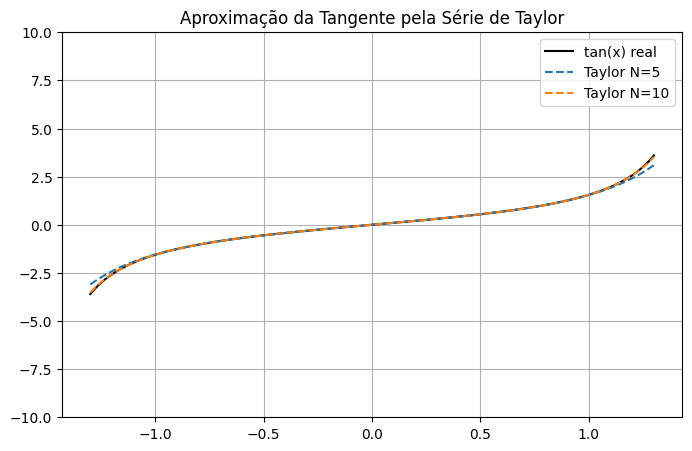

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(-1.3, 1.3, 200)
real_vals = np.tan(x_vals)
taylor5 = [Tan_taylor(x, 5) for x in x_vals]
taylor10 = [Tan_taylor(x, 10) for x in x_vals]

plt.figure(figsize=(8,5))
plt.plot(x_vals, real_vals, label="tan(x) real", color="black")
plt.plot(x_vals, taylor5, "--", label="Taylor N=5")
plt.plot(x_vals, taylor10, "--", label="Taylor N=10")
plt.ylim(-10, 10)
plt.legend()
plt.title("Aproximação da Tangente pela Série de Taylor")
plt.grid()
plt.show()


Para $|x| < 1$, a aproximação de ordem $5$ acompanha bem a função real. Já com $N = 5$, a aproximação é mis precisa até valores próximos de 1.3 rad. Preto das assítotas $\frac{π}{2}$, a série não consegue reproduzir o crescimento da tangente.  

#### Erro em função de $x$ ($N=5$ e $N=10$)

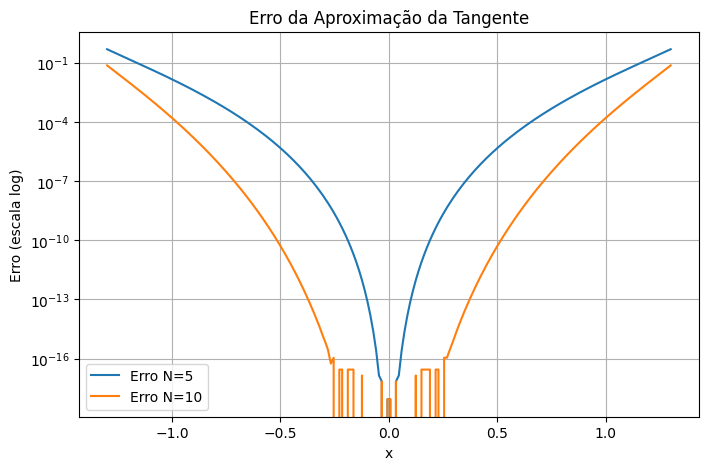

In [9]:
errors5 = [abs(math.tan(x) - Tan_taylor(x, 5)) for x in x_vals]
errors10 = [abs(math.tan(x) - Tan_taylor(x, 10)) for x in x_vals]

plt.figure(figsize=(8,5))
plt.semilogy(x_vals, errors5, label="Erro N=5")
plt.semilogy(x_vals, errors10, label="Erro N=10")
plt.title("Erro da Aproximação da Tangente")
plt.xlabel("x")
plt.ylabel("Erro (escala log)")
plt.legend()
plt.grid()
plt.show()


O erro cresce conforme $x$ se aproxima de $\frac{π}{2}$. Para valores pequenos de $x$, tanto $N = 5$ como $N = 10$ apresentam erro muito pequeno, mas a aproximação com 10 termos se mantem estavel por mais tempo.

#### "Erro em função de $N$ $(x=\frac{π}{4})$:

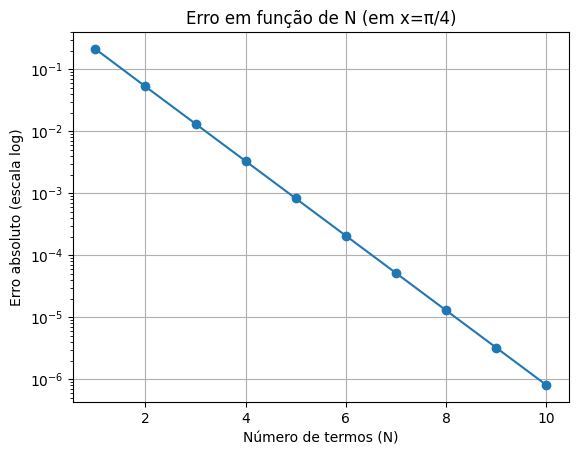

In [10]:
Ns = range(1, 11)
erro_vs_N = [abs(math.tan(math.pi/4) - Tan_taylor(math.pi/4, N)) for N in Ns]

plt.plot(Ns, erro_vs_N, marker="o")
plt.yscale("log")
plt.title("Erro em função de N (em x=π/4)")
plt.xlabel("Número de termos (N)")
plt.ylabel("Erro absoluto (escala log)")
plt.grid()
plt.show()


Podemos notar a quenda de erro com o aumento de $N$. Para $N = 10$, o erro já fica menor que $10^{-6}$.

#### Tempo de execução em função de $N$:

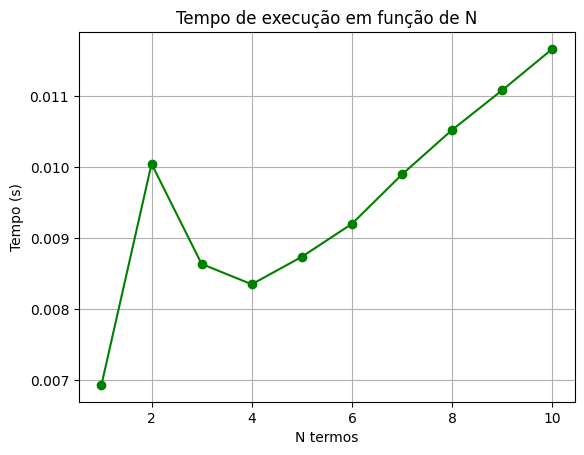

In [11]:
import time

tempos = []
for N in Ns:
    start = time.time()
    for _ in range(10000):
        Tan_taylor(1.0, N)
    end = time.time()
    tempos.append(end-start)

plt.plot(Ns, tempos, marker="o", color="green")
plt.title("Tempo de execução em função de N")
plt.xlabel("N termos")
plt.ylabel("Tempo (s)")
plt.grid()
plt.show()


O tempo cresce linermente com o número de termos da série, mas permanece pequeno mesmo para $N = 20$, mostrando que a aproximação é eficiente.

#### Conclusão:

O estudo da função $tan(x)$ pela série de Taylor mostrou que a aproximação é eficiente no intervalo $|x| < \frac{π}{2}$, onde apenas potências ímpares aparecem na expansão. A análise de erro indicou que $N = 10$ é suficiente para obter precisão melhor que $10^{-6}$, resultado confirmado nas tabelas e gráficos. O tempo de execução cresce linearmente com $N$, mas permanece baixo, tornando o método prático. Além disso, a implementação tan_manual confirmou a validade dos cálculos. Conclui-se que a série de Taylor da tangente é precisa e computacionalmente viável nesse domínio